# **How Kernel Choice Changes Decision Boundaries in SVM**

Support Vector Machines (SVM) are a commonly used method used in machine learning for classification problems. The main idea behind SVM is to find a boundary that best separates different classes in a dataset.

However, not all datasets can be separated using a straight line. In many real-world situations, the relationship between data points is more complex. This is where kernel functions become useful, as they allow SVM to handle non-linear data by transforming it into a different space.

In this tutorial, I explore how different kernel choices affect the decision boundaries of an SVM model. Using a non-linear dataset, I compare linear, polynomial, and RBF kernels to show how each one performs and why the choice of kernel matters.

## **Intuition**

The main idea behind Support Vector Machines is to find a boundary that separates data points into different classes as clearly as possible. In simple cases, this boundary can be a straight line (or a flat plane in higher dimensions).

However, not all datasets are that simple. Some data cannot be separated using a straight line because the classes are arranged in a more complex way. In these situations, a linear model will struggle to perform well.

Kernels help solve this problem by transforming the data into a higher-dimensional space. In this new space, it becomes easier to draw a boundary that separates the classes. Even though the boundary may look complex in the original space, the kernel makes it possible for SVM to handle these non-linear patterns effectively.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons

## **Dataset**

We use the `make_moons` dataset, which is non-linearly separable. This makes it ideal for demonstrating how different kernels behave.

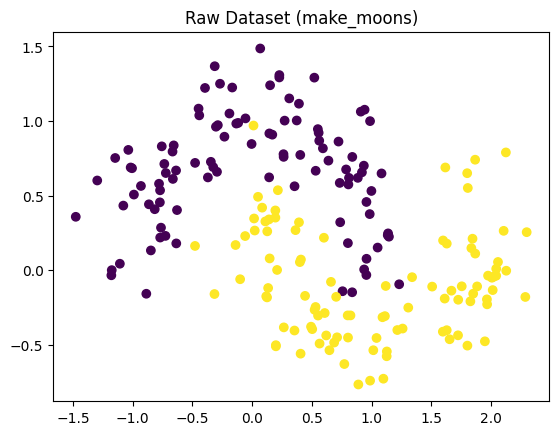

In [15]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Raw Dataset (make_moons)")
plt.show()

## **Training SVM Models**

We train three SVM models using different kernels:
- Linear kernel
- Polynomial kernel
- RBF kernel

> Add blockquote



In [16]:
# Train SVM models with different kernels

linear_model = svm.SVC(kernel='linear')
poly_model = svm.SVC(kernel='poly', degree=3)
rbf_model = svm.SVC(kernel='rbf')

linear_model.fit(X, y)
poly_model.fit(X, y)
rbf_model.fit(X, y)

SVC()

In [17]:
def plot_decision_boundary(model, X, y, title):
    plt.figure()

    # Create grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict over grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y)

    plt.title(title)
    plt.show()

## **Decision Boundaries**
We visualise how each model separates the data.

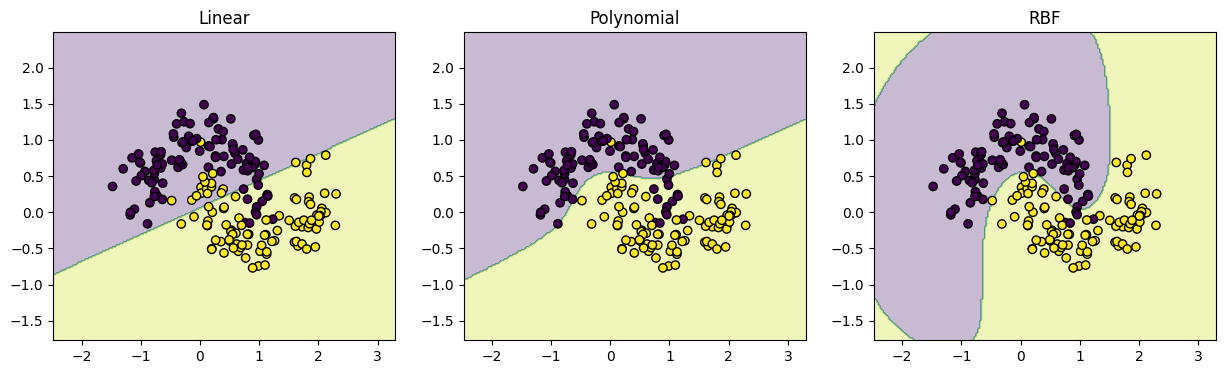

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [linear_model, poly_model, rbf_model]
titles = ["Linear", "Polynomial", "RBF"]

for ax, model, title in zip(axes, models, titles):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    ax.set_title(title)

plt.show()

## **Results and Analysis**

### **Linear Kernel**
The linear kernel produces a straight decision boundary. This does not fit the dataset well because the data is not linearly separable. As a result, several points are misclassified.

### **Polynomial Kernel**
The polynomial kernel introduces a curved boundary, which improves the model’s ability to separate the data. It performs better than the linear kernel, but still does not perfectly capture the structure of the dataset.

### **RBF Kernel**
The RBF kernel creates a more flexible decision boundary that closely follows the shape of the data. This allows it to separate the classes much more effectively than the other kernels.

### **Key Insight**
These results show that kernel choice plays a critical role in SVM performance. Linear kernels are limited to simple patterns, while non-linear kernels such as polynomial and RBF can handle more complex data structures.

## **Conclusion**

In this tutorial, we explored how different kernel choices affect the performance of Support Vector Machines. By comparing linear, polynomial, and RBF kernels on a non-linear dataset, we observed clear differences in how each model behaves.

The linear kernel struggled to separate the data, while the polynomial kernel showed some improvement. The RBF kernel performed the best, as it was able to model the complex structure of the dataset.

Overall, this demonstrates that selecting the right kernel is essential when using SVM, especially when working with non-linear data.

## **References**
- Scikit-learn Documentation: https://scikit-learn.org/stable/modules/svm.html
- Cortes, C., & Vapnik, V. (1995). Support-vector networks.
- Towards Data Science blog on SVM kernels